# Custom Calibrators

The following tutorial demonstrates how one may create a custom calibrator to perform your own calibration workflows.

In [1]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import differential_evolution

from calisim.base import CalibrationWorkflowBase
from calisim.data_model import (
	DistributionModel,
	ParameterDataType,
	ParameterSpecification,
)
from calisim.data_model import ParameterDataType, ParameterEstimateModel

from calisim.example_models import LotkaVolterraModel
from calisim.optimisation import OptimisationMethod, OptimisationMethodModel
from calisim.statistics import MeanSquaredError

import warnings
warnings.filterwarnings("ignore")

## Creating a Calibrator

Let's create a custom calibrator called `SciPyDEOptimisation` that uses [SciPy's](https://scipy.org/) differential evolution algorithm for calibrating models via black-box optimisation. All custom calibrators must inherit from the `CalibrationWorkflowBase` abstract class.

```python
class SciPyDEOptimisation(CalibrationWorkflowBase):
    """The SciPy differential evolution optimisation method class."""
```

The `CalibrationWorkflowBase` class defines three abstract methods which must be implemented by your calibrator:

- `specify()`: Specify the parameters of the model calibration procedure.
- `execute()`: Execute the simulation calibration procedure.
- `analyze()`: Analyze the results of the simulation calibration procedure.

### Specify

Let's first define `specify()`:

```python
def specify(self) -> None:
    """Specify the parameters of the model calibration procedure."""
    self.names = []
    self.data_types = []
    self.bounds = []
    
    parameter_spec = self.specification.parameter_spec.parameters
    for spec in parameter_spec:
        parameter_name = spec.name
        data_type = spec.data_type
    
        if data_type == ParameterDataType.CONSTANT:
            parameter_value = spec.parameter_value
            self.constants[parameter_name] = parameter_value
            continue
        elif data_type == ParameterDataType.CATEGORICAL:
            bounds = self.set_categorical_parameter(spec)
        else:
            bounds = self.get_parameter_bounds(spec)  
    
        self.names.append(parameter_name)
        self.data_types.append(data_type)
        self.bounds.append(bounds)
```

We can see that our calibrator loops through each parameter specification within a `ParameterSpecification` collection object. 

`CalibrationWorkflowBase` has a `constants` dictionary for storing **CONSTANT** parameter data types. `CalibrationWorkflowBase` defines a method called `set_categorical_parameter()` for dealing with **CATEGORICAL** data, which returns lower and upper parameter bounds. For **CONTINUOUS** and **DISCRETE** data, `CalibrationWorkflowBase` defines a method called `get_parameter_bounds()` which returns the lower and upper parameter bounds. 

Finally, we store the parameter names, data types, and bounds within three lists.

### Execute

Let's next define `execute()`:

```python
def execute(self) -> None:
    """Execute the simulation calibration procedure."""
    optimisation_kwargs = self.get_calibration_func_kwargs()

    self.history = []
    self.eval_count = 0
    output_labels = self.specification.output_labels
    if output_labels is None:
        output_labels = ["target"]
        
    def target_function(X: np.ndarray) -> np.ndarray:
        X_dict = {
            name: X[i]
            for i, name in enumerate(self.names)
        }
        X = [X]
        
        Y = self.calibration_func_wrapper(
            X,
            self,
            self.specification.observed_data,
            self.names,
            self.data_types,
            optimisation_kwargs,
        )

        X_dict["eval_count"] = self.eval_count
        self.eval_count += 1
        X_dict[output_labels[0]] = Y
        self.history.append(X_dict)
    
        return Y
    
    n_iterations = self.specification.n_iterations
    verbose = self.specification.verbose
    n_jobs = self.specification.n_jobs
    random_seed = self.specification.random_seed

    method_kwargs = self.specification.method_kwargs
    if method_kwargs is None:
        method_kwargs = {}
            
    self.study = differential_evolution(
        target_function,
        self.bounds,
        maxiter=n_iterations,
        disp=verbose,
        workers=n_jobs,
        seed=random_seed,
        **method_kwargs
    )
```

The `CalibrationWorkflowBase` class defines a getter method called `get_calibration_func_kwargs()` that retrieves the `calibration_func_kwargs` values supplied to the `OptimisationMethodModel` object's constructor. This allows us to include custom arguments within our objective function. 

Our `SciPyDEOptimisation` class will store the trial history and number of objective function evaluations using two properties (`self.history` and `self.eval_count`). We specify the names of our objectives using the `output_labels` field within our `OptimisationMethodModel` specification.

We define a function called `target_function()` which will be executed by the differential evolution algorithm. This function calls the `calibration_func_wrapper()` method, which is defined by our `CalibrationWorkflowBase` base class. `calibration_func_wrapper()` will perform some data preprocessing and call our objective function under the hood.

We retrieve several `OptimisationMethodModel` specification values:

- `n_iterations`: The number of trial iterations for optimisation.
- `verbose`: The verbosity of the calibration procedure. How much detail is provided in the outputs.
- `n_jobs`: The number of jobs to run for parallel processing.
- `random_seed`: The random seed for replicability due to stochasticity.
- `method_kwargs`: Named arguments to pass to the calibration procedure when the default values are insufficient.

Finally, we execute the `differential_evolution()` algorithm to perform calibration.

### Analyze

We must next define `analyze()`:

```python
def analyze(self) -> None:
    """Analyze the results of the simulation calibration procedure."""
    task, time_now, experiment_name, outdir = self.prepare_analyze()

    output_labels = self.specification.output_labels
    if output_labels is None:
        output_labels = ["target"]
        
    trials_df = pd.DataFrame(self.history)
    trials_df_best = trials_df.sort_values(output_labels).head(1)
    for col in trials_df_best.columns:
        if col in output_labels or col == "eval_count":
            continue
        estimate = trials_df_best[col].item()
        parameter_estimate = ParameterEstimateModel(name=col, estimate=estimate)
        self.add_parameter_estimate(parameter_estimate)

    for output_label in output_labels:
        ax  = trials_df.plot.scatter("eval_count", output_label, figsize=self.specification.figsize)
        fig = ax.get_figure()
        ax.set_title(f"Optimisation history: {output_label}")
        
        self.present_fig(
            fig, outdir, time_now, task, experiment_name, f"plot-optimization-history-{output_label}"
        )

    fig, axes = plt.subplots(nrows = len(self.names), figsize=self.specification.figsize)
    for i, name in enumerate(self.names):
        trials_df.plot.scatter(name, "eval_count", ax=axes[i])
        axes[i].invert_yaxis()
        axes[i].set_title(f"Parameter: {name}")
    self.present_fig(
        fig, outdir, time_now, task, experiment_name, "plot-slice"
    )
        
    if outdir is None:
        return
    
    self.to_csv(trials_df, "trials")

```

The `prepare_analyze()` method retrieves several values which are needed to store data to file.

From our `self.history` property, we can construct a trial history [Pandas dataframe](https://pandas.pydata.org/). We retrieve the best trial from the dataframe, and thereafter save the optimised parameter estimates within `ParameterEstimateModel` objects, which are then added to a list of parameter estimates via the `add_parameter_estimate()` method.

We loop through each named objective (`output_labels`) and construct a scatter plot visualising the relationship between the objective values and the trial evaluation number. The `CalibrationWorkflowBase` class defines the `present_fig()` method which will either save the scatter plot to file or directly render and open the plot to the user's screen. We also loop through each named parameter (`self.names`) and similarly create scatter plots to visualise the relationship between parameter values and the trial evaluation number. 

Finally, if the `outdir` directory is provided, we save the trial history dataframe as a `csv` file.

Let's put all of this code together into one `SciPyDEOptimisation` class: 

In [2]:
class SciPyDEOptimisation(CalibrationWorkflowBase):
    """The SciPy differential evolution optimisation method class."""

    def specify(self) -> None:
        """Specify the parameters of the model calibration procedure."""
        self.names = []
        self.data_types = []
        self.bounds = []
        
        parameter_spec = self.specification.parameter_spec.parameters
        for spec in parameter_spec:
            parameter_name = spec.name
            data_type = spec.data_type
        
            if data_type == ParameterDataType.CONSTANT:
                parameter_value = spec.parameter_value
                self.constants[parameter_name] = parameter_value
                continue
            elif data_type == ParameterDataType.CATEGORICAL:
                bounds = self.set_categorical_parameter(spec)
            else:
                bounds = self.get_parameter_bounds(spec)  
        
            self.names.append(parameter_name)
            self.data_types.append(data_type)
            self.bounds.append(bounds)

    def execute(self) -> None:
        """Execute the simulation calibration procedure."""
        optimisation_kwargs = self.get_calibration_func_kwargs()

        self.history = []
        self.eval_count = 0
        output_labels = self.specification.output_labels
        if output_labels is None:
            output_labels = ["target"]
            
        def target_function(X: np.ndarray) -> np.ndarray:
            X_dict = {
                name: X[i]
                for i, name in enumerate(self.names)
            }
            X = [X]
            
            Y = self.calibration_func_wrapper(
                X,
                self,
                self.specification.observed_data,
                self.names,
                self.data_types,
                optimisation_kwargs,
            )

            X_dict["eval_count"] = self.eval_count
            self.eval_count += 1
            X_dict[output_labels[0]] = Y
            self.history.append(X_dict)
        
            return Y
        
        n_iterations = self.specification.n_iterations
        verbose = self.specification.verbose
        n_jobs = self.specification.n_jobs
        random_seed = self.specification.random_seed

        method_kwargs = self.specification.method_kwargs
        if method_kwargs is None:
            method_kwargs = {}
                
        self.study = differential_evolution(
            target_function,
            self.bounds,
            maxiter=n_iterations,
            disp=verbose,
            workers=n_jobs,
            seed=random_seed,
            **method_kwargs
        )

    def analyze(self) -> None:
        """Analyze the results of the simulation calibration procedure."""
        task, time_now, experiment_name, outdir = self.prepare_analyze()

        output_labels = self.specification.output_labels
        if output_labels is None:
            output_labels = ["target"]
            
        trials_df = pd.DataFrame(self.history)
        trials_df_best = trials_df.sort_values(output_labels).head(1)
        for col in trials_df_best.columns:
            if col in output_labels or col == "eval_count":
                continue
            estimate = trials_df_best[col].item()
            parameter_estimate = ParameterEstimateModel(name=col, estimate=estimate)
            self.add_parameter_estimate(parameter_estimate)

        for output_label in output_labels:
            ax  = trials_df.plot.scatter("eval_count", output_label, figsize=self.specification.figsize)
            fig = ax.get_figure()
            ax.set_title(f"Optimisation history: {output_label}")
            
            self.present_fig(
                fig, outdir, time_now, task, experiment_name, f"plot-optimization-history-{output_label}"
            )

        fig, axes = plt.subplots(nrows = len(self.names), figsize=self.specification.figsize)
        for i, name in enumerate(self.names):
            trials_df.plot.scatter(name, "eval_count", ax=axes[i])
            axes[i].invert_yaxis()
            axes[i].set_title(f"Parameter: {name}")
        self.present_fig(
            fig, outdir, time_now, task, experiment_name, "plot-slice"
        )
            
        if outdir is None:
            return
        
        self.to_csv(trials_df, "trials")

## Performing Calibration

That covers the end-to-end process of creating a custom calibrator. Let's try calibrating an example model: `LotkaVolterraModel`.

In [3]:
model = LotkaVolterraModel()
observed_data = model.get_observed_data()
observed_data.head(5)

,year,lynx,hare
0,1900.0,4.0,30.0
1,1901.0,6.1,47.2
2,1902.0,9.8,70.2
3,1903.0,35.2,77.4
4,1904.0,59.4,36.3


We'll define our parameter specification containing parameter names, data types, distribution types, and bounds.

In [4]:
parameter_spec = ParameterSpecification(
	parameters=[
		DistributionModel(
			name="alpha",
			distribution_name="uniform",
			distribution_args=[0.45, 0.55],
			data_type=ParameterDataType.CONTINUOUS,
		),
		DistributionModel(
			name="beta",
			distribution_name="uniform",
			distribution_args=[0.02, 0.03],
			data_type=ParameterDataType.CONTINUOUS,
		),
	]
)

We'll define our objective function. We aim to minimise the discrepancy between simulated and observed data using the `MeanSquaredError` metric as our loss.

In [5]:
def objective(
	parameters: dict, simulation_id: str, observed_data: np.ndarray | None, t: pd.Series
) -> float | list[float]:
	simulation_parameters = dict(h0=34.0, l0=5.9, t=t, gamma=0.84, delta=0.026)

	for k in ["alpha", "beta"]:
		simulation_parameters[k] = parameters[k]

	simulated_data = model.simulate(simulation_parameters).lynx.values
	metric = MeanSquaredError()
	discrepancy = metric.calculate(observed_data, simulated_data)
	return discrepancy

We'll define the specification for the differential evolution optimisation procedure. This will include the number of opimisation iterations (`n_iterations`), the name of the optimisation objectives (`output_labels`), and the named arguments to pass to SciPy's differential evolution function (`method_kwargs`).

In [6]:
specification = OptimisationMethodModel(
	experiment_name="scipy_optimisation",
	parameter_spec=parameter_spec,
	observed_data=observed_data.lynx.values,
	n_iterations=100,
	output_labels=["Lynx"],
	method_kwargs=dict(
		init='latinhypercube',
        popsize=15
	),
	calibration_func_kwargs=dict(t=observed_data.year),
)


Finally, let's run the calibration workflow by instantiating an `OptimisationMethod` calibrator, and subsequently calling the `specify()`, `execute()`, and `analyze()` methods.

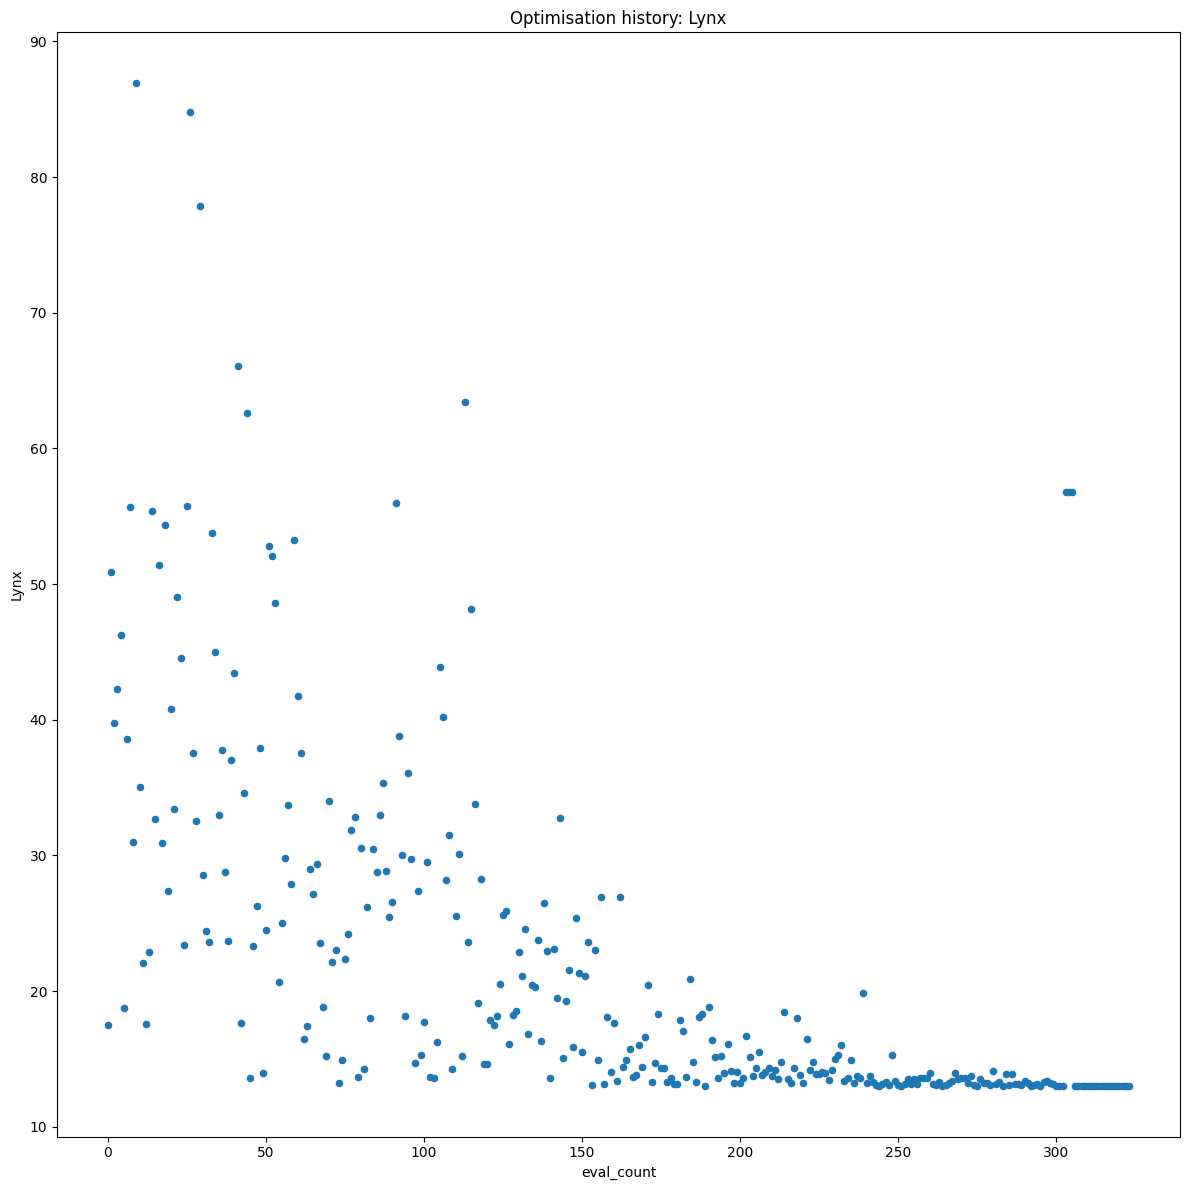

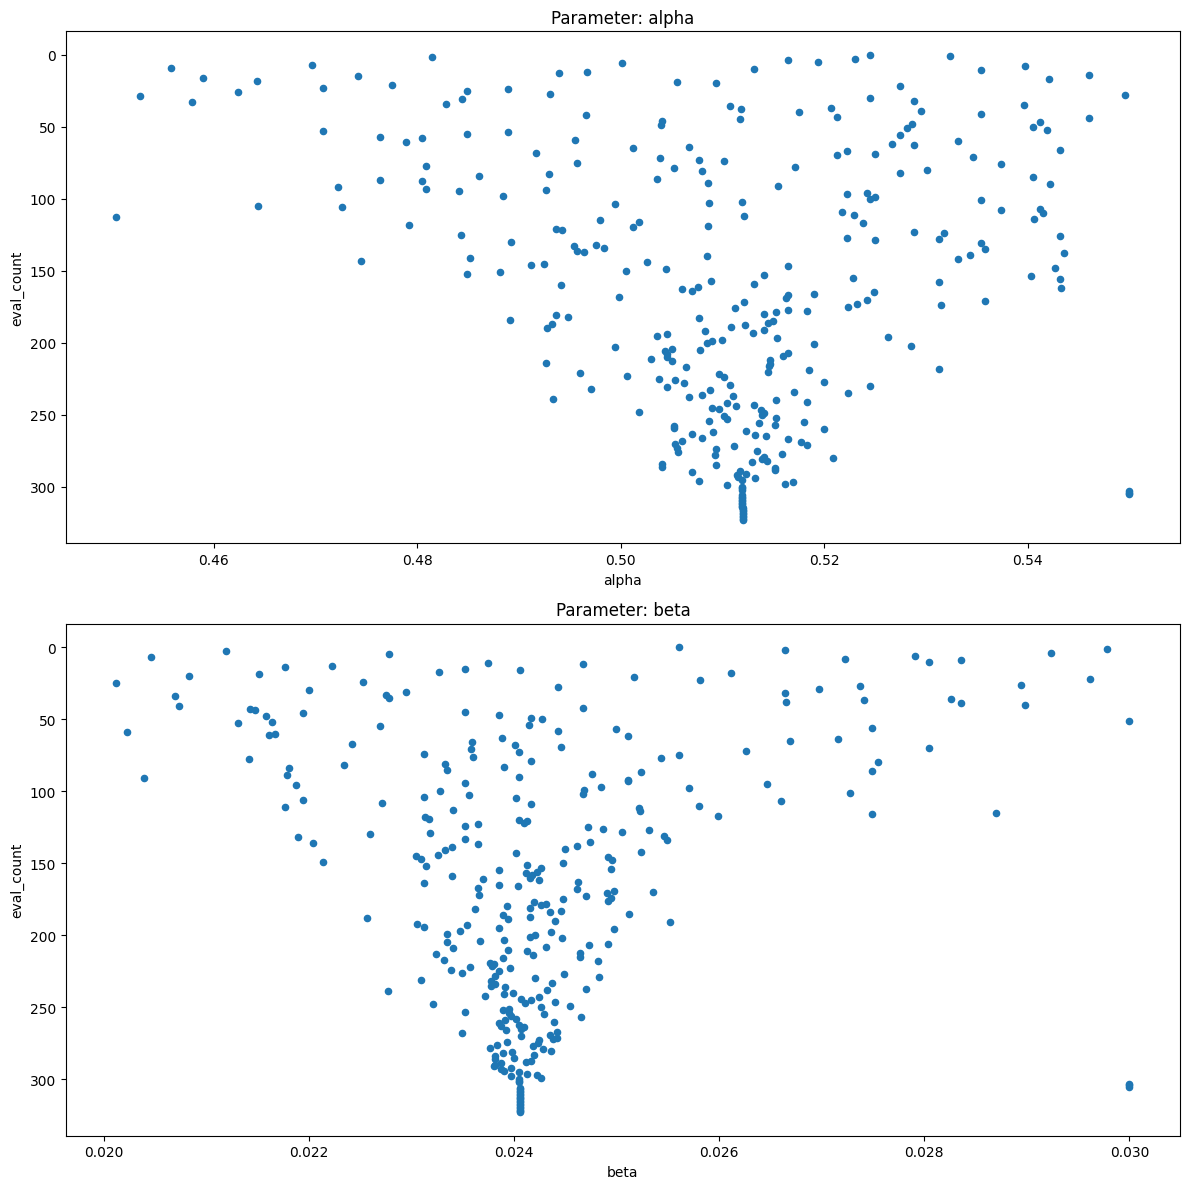

In [7]:
calibrator = OptimisationMethod(
	calibration_func=objective, 
    specification=specification, 
    implementation=SciPyDEOptimisation
)

calibrator.specify().execute().analyze()

The differential evolution algorithm was able to recover the ground truth parameters for the simulation study.

In [8]:
pd.DataFrame([
    { "parameter": estimate.name, "estimate": estimate.estimate, "ground truth": model.GROUND_TRUTH[estimate.name] }
    for estimate in calibrator.get_parameter_estimates().estimates
])

,parameter,estimate,ground truth
0,alpha,0.512032,0.520
1,beta,0.024060,0.024
